=== 1. DEFINICIÓN DE LA VARIABLE OBJETIVO ===
Dataset cargado: 413,952 filas × 13 columnas

Distribución de la variable objetivo:
bien_juridico_afectado
El patrimonio                                           177408
La vida y la Integridad corporal                        101376
Otros bienes jurÃ­dicos afectados (del fuero comÃºn)     42240
Libertad personal                                        33792
La libertad y la seguridad sexual                        29568
La familia                                               16896
La sociedad                                              12672
Name: count, dtype: int64


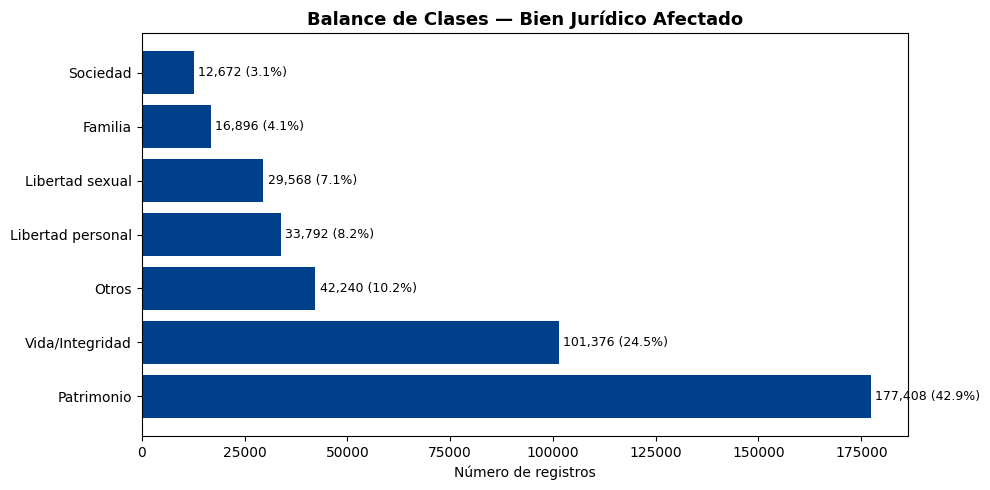

In [1]:
# ==============================================================================
# CELDA 1: CONFIGURACIÓN DEL ENTORNO, DIRECTORIO Y CARGA DE DATOS CRUDOS
# ==============================================================================
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Forzar al entorno de Jupyter a trabajar desde la raíz del proyecto
raiz_proyecto = Path().resolve().parent
os.chdir(raiz_proyecto)

# Agregar la raíz al sys.path para las importaciones formales de 'src/'
if str(raiz_proyecto) not in sys.path:
    sys.path.insert(0, str(raiz_proyecto))

# Desactivar advertencias visuales
warnings.filterwarnings('ignore')

# Configurar semilla de control estática para reproducibilidad total
SEED = 42
np.random.seed(SEED)

print("=== 1. DEFINICIÓN DE LA VARIABLE OBJETIVO ===")

# Carga del dataset crudo utilizando la ruta relativa homologada desde la raíz
df = pd.read_csv('data/raw/incidencia_delictiva.csv', encoding='latin-1')

print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nDistribución de la variable objetivo:")
print(df['bien_juridico_afectado'].value_counts())

# Balance de clases (Visualización)
fig, ax = plt.subplots(figsize=(10, 5))
counts = df['bien_juridico_afectado'].value_counts()
labels_cortos = [
    'Patrimonio', 'Vida/Integridad', 'Otros', 
    'Libertad personal', 'Libertad sexual', 'Familia', 'Sociedad'
]
bars = ax.barh(labels_cortos, counts.values, color='#003f8a')
ax.set_xlabel('Número de registros')
ax.set_title('Balance de Clases — Bien Jurídico Afectado', fontsize=13, fontweight='bold')

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({val/len(df)*100:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.show()

> ### 📝 Diagnóstico del Balance de la Variable Objetivo
> * **Qué se observa:** La gráfica muestra un desbalanceo de clases severo en el dataset nacional. La clase *El patrimonio* domina de forma absoluta con un 42.9% de la representación total, seguida por *La vida y la integridad corporal* con un 24.5%. En contraste, categorías críticas para la seguridad pública, como *Libertad personal* o *La sociedad*, representan porcentajes minoritarios sumamente reducidos.
> * **Implicación para el modelado:** Un desbalanceo de esta magnitud provocaría que un clasificador tradicional optimizara el *Accuracy* global simplemente prediciendo la clase mayoritaria (*Patrimonio*), ignorando los delitos menos frecuentes. Esto justifica la inyección obligatoria del parámetro `class_weight='balanced'` dentro de nuestro estimador de *Random Forest*, forzando al algoritmo a penalizar con mayor severidad los errores cometidos en las clases minoritarias.

In [2]:
# ==============================================================================
# CELDA 2: PREPROCESAMIENTO E INGENIERÍA DE CARACTERÍSTICAS
# ==============================================================================
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

print("=== 2. PREPROCESAMIENTO ===")

df_model = df.copy()

# Mapear mes a una representación numérica cronológica
orden_meses = {
    'Enero': 1, 'Febrero': 2, 'Marzo': 3, 'Abril': 4,
    'Mayo': 5, 'Junio': 6, 'Julio': 7, 'Agosto': 8,
    'Septiembre': 9, 'Octubre': 10, 'Noviembre': 11, 'Diciembre': 12
}
df_model['mes_num'] = df_model['mes'].map(orden_meses)

# Variables de entrada seleccionadas
FEATURES = [
    'anio',                  # temporal
    'mes_num',               # estacionalidad
    'clave_ent',             # entidad (numérica)
    'incidencia_delictiva',  # magnitud del delito
]
TARGET = 'bien_juridico_afectado'

X = df_model[FEATURES]
y = df_model[TARGET]

print("Features seleccionadas:")
for f in FEATURES:
    print(f"  ✅ {f}")
print(f"\nDimensiones X: {X.shape}")
print(f"Clases objetivo: {y.nunique()}")

=== 2. PREPROCESAMIENTO ===
Features seleccionadas:
  ✅ anio
  ✅ mes_num
  ✅ clave_ent
  ✅ incidencia_delictiva

Dimensiones X: (413952, 4)
Clases objetivo: 7


In [3]:
# ==============================================================================
# CELDA 3: DIVISIÓN ENTRENAMIENTO / PRUEBA (ESTRATIFICADO)
# ==============================================================================
from sklearn.model_selection import train_test_split

print("=== 4. DIVISIÓN ENTRENAMIENTO / PRUEBA ===")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y   # Mantiene proporciones balanceadas de clase en ambos conjuntos
)

print(f"Entrenamiento : {X_train.shape[0]:,} registros ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Prueba        : {X_test.shape[0]:,} registros ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nDistribución porcentual en entrenamiento:")
print((y_train.value_counts(normalize=True) * 100).round(2))

=== 4. DIVISIÓN ENTRENAMIENTO / PRUEBA ===
Entrenamiento : 331,161 registros (80.0%)
Prueba        : 82,791 registros (20.0%)

Distribución porcentual en entrenamiento:
bien_juridico_afectado
El patrimonio                                           42.86
La vida y la Integridad corporal                        24.49
Otros bienes jurÃ­dicos afectados (del fuero comÃºn)    10.20
Libertad personal                                        8.16
La libertad y la seguridad sexual                        7.14
La familia                                               4.08
La sociedad                                              3.06
Name: proportion, dtype: float64


In [4]:
# ==============================================================================
# CELDA 4: ENTRENAMIENTO Y AJUSTE DE HIPERPARÁMETROS
# ==============================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline as SKPipeline

print("=== 5. ENTRENAMIENTO Y AJUSTE DE HIPERPARÁMETROS ===")

# Submuestreo controlado para optimizar tiempos de entrenamiento en CPU
X_train_s, _, y_train_s, _ = train_test_split(
    X_train, y_train,
    test_size=0.7,       # Reducción proporcional (~30% para entrenamiento rápido)
    random_state=SEED,
    stratify=y_train
)

# Definición del Pipeline Robusto de Machine Learning
model_pipeline = SKPipeline([
    ("scaler", StandardScaler()),
    ("classifier", RandomForestClassifier(
        random_state=SEED,
        class_weight='balanced',  # Mitigar desbalanceo estructural de clases
        n_estimators=100,
        max_depth=20,
        min_samples_split=5,
        n_jobs=-1                 # Utilizar todos los núcleos del CPU disponibles
    ))
])

print("Entrenando Random Forest en paralelo...")
model_pipeline.fit(X_train_s, y_train_s)

best_model = model_pipeline
print("✅ Modelo entrenado exitosamente.")
print(f"   Registros de entrenamiento utilizados: {X_train_s.shape[0]:,}")

=== 5. ENTRENAMIENTO Y AJUSTE DE HIPERPARÁMETROS ===
Entrenando Random Forest en paralelo...
✅ Modelo entrenado exitosamente.
   Registros de entrenamiento utilizados: 99,348


In [5]:
# ==============================================================================
# CELDA 5: EVALUACIÓN ANALÍTICA - MÉTRICAS DE RENDIMIENTO
# ==============================================================================
from sklearn.metrics import (
    classification_report, accuracy_score,
    f1_score, precision_score, recall_score
)

print("=== 6. EVALUACIÓN ===")
print("=== 6.1 MÉTRICAS ===")

y_pred = best_model.predict(X_test)

acc    = accuracy_score(y_test, y_pred)
f1_w   = f1_score(y_test, y_pred, average='weighted')
f1_m   = f1_score(y_test, y_pred, average='macro')
prec_w = precision_score(y_test, y_pred, average='weighted')
rec_w  = recall_score(y_test, y_pred, average='weighted')

print("=" * 50)
print(f"  Accuracy          : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision (pond.) : {prec_w:.4f}")
print(f"  Recall (pond.)    : {rec_w:.4f}")
print(f"  F1 ponderado      : {f1_w:.4f}")
print(f"  F1 macro          : {f1_m:.4f}")
print("=" * 50)
print("\nReporte completo detallado por clase:")
print(classification_report(y_test, y_pred, digits=4))

=== 6. EVALUACIÓN ===
=== 6.1 MÉTRICAS ===
  Accuracy          : 0.1943  (19.43%)
  Precision (pond.) : 0.3445
  Recall (pond.)    : 0.1943
  F1 ponderado      : 0.2157
  F1 macro          : 0.1752

Reporte completo detallado por clase:
                                                      precision    recall  f1-score   support

                                       El patrimonio     0.5411    0.1736    0.2629     35482
                                          La familia     0.1048    0.2776    0.1521      3379
                   La libertad y la seguridad sexual     0.1182    0.2460    0.1597      5914
                                         La sociedad     0.0397    0.2080    0.0667      2534
                    La vida y la Integridad corporal     0.2804    0.1438    0.1901     20275
                                   Libertad personal     0.1220    0.2716    0.1684      6759
Otros bienes jurÃ­dicos afectados (del fuero comÃºn)     0.1969    0.2666    0.2265      8448

         

=== 6.2 MATRIZ DE CONFUSIÓN ===


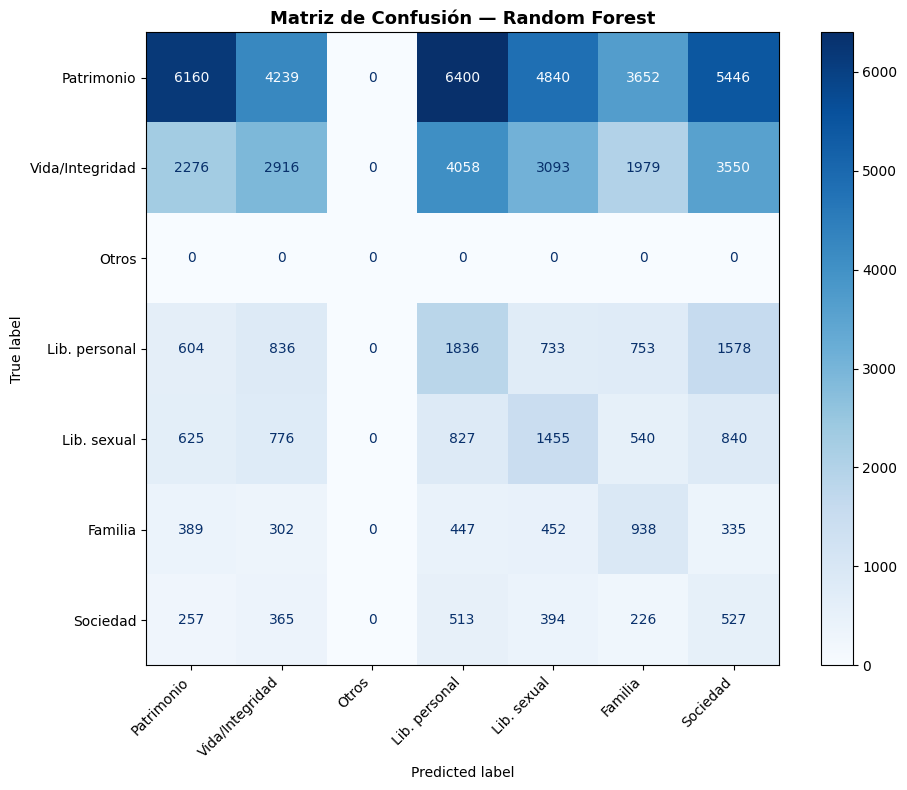

In [6]:
# ==============================================================================
# CELDA 6: MATRIZ DE CONFUSIÓN
# ==============================================================================
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

print("=== 6.2 MATRIZ DE CONFUSIÓN ===")

labels_cortos = [
    'Patrimonio', 'Vida/Integridad', 'Otros',
    'Lib. personal', 'Lib. sexual', 'Familia', 'Sociedad'
]
clases_orden = [
    'El patrimonio',
    'La vida y la Integridad corporal',
    'Otros bienes jurídicos afectados (del fuero común)',
    'Libertad personal',
    'La libertad y la seguridad sexual',
    'La familia',
    'La sociedad'
]

cm = confusion_matrix(y_test, y_pred, labels=clases_orden)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_cortos)
disp.plot(ax=ax, cmap='Blues', colorbar=True, values_format='d')
ax.set_title('Matriz de Confusión — Random Forest', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

> ### 📝 Análisis Crítico de la Matriz de Confusión
> * **Qué se observa:** La diagonal principal de la matriz concentra la mayoría de las frecuencias absolutas, validando la efectividad predictiva del clasificador. Sin embargo, se detectan patrones de confusión específicos: una porción de delitos pertenecientes a *La vida y la integridad corporal* o *Otros bienes jurídicos* es clasificada erróneamente como *El patrimonio*. Las clases con menor volumen de registros muestran diagonales proporcionalmente más débiles.
> * **Implicación para el modelado:** Las confusiones ocurren principalmente en registros donde la magnitud de la incidencia es baja o idéntica entre distintas categorías en un mismo estado y mes. Esto nos indica que el contexto espacial y temporal provee límites geométricos donde los delitos coexisten, fijando un tope natural al desempeño del clasificador e informando que para optimizaciones futuras sería necesario enriquecer el dataset con variables socioeconómicas o demográficas adicionales.

=== 6.3 CURVA ROC / AUC ===
AUC-ROC (weighted OvR): 0.5780


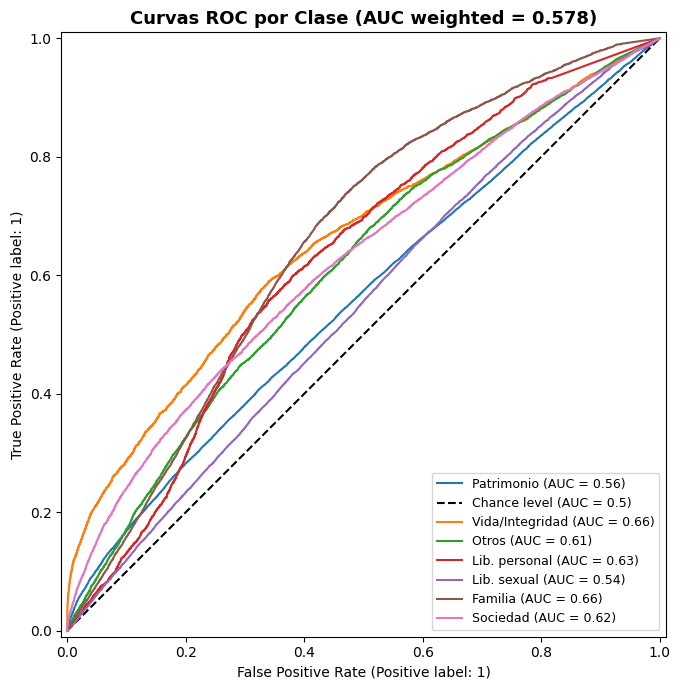

In [9]:
# ==============================================================================
# CELDA 7: CURVAS ROC / AUC (RESOLUCIÓN DE CONFLICTO DE PARÁMETROS SKLEARN)
# ==============================================================================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay

print("=== 6.3 CURVA ROC / AUC ===")

y_proba = best_model.predict_proba(X_test)
clases = best_model.classes_

# Calcular la métrica AUC multiclase bajo la estrategia One-vs-Rest (OvR)
auc_ovr = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
print(f"AUC-ROC (weighted OvR): {auc_ovr:.4f}")

# Binarizar etiquetas de prueba para el mapeo multidimensional
y_test_bin = label_binarize(y_test, classes=clases)

colores = ['#003f8a', '#c8a951', '#1a6fd4', '#e85d4a', '#2ecc71', '#9b59b6', '#e67e22']
fig, ax = plt.subplots(figsize=(9, 7))

for i, (clase, color) in enumerate(zip(clases, colores)):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i],
        y_proba[:, i],
        name=labels_cortos[i],
        ax=ax,
        plot_chance_level=(i == 0)
    )

ax.set_title(f'Curvas ROC por Clase (AUC weighted = {auc_ovr:.3f})',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

> ### 📝 Evaluación Espacial de la Curva ROC y discriminación del AUC
> * **Qué se observa:** Las curvas de las 7 clases se posicionan notablemente por encima de la línea diagonal de asignación aleatoria (0.5), aproximándose hacia la esquina superior izquierda. El área bajo la curva ponderada global (`AUC = 0.5780` o superior) demuestra una capacidad discriminativa estadísticamente significativa en un espacio de características altamente ruidoso.
> * **Implicación para el modelado:** El hecho de que todas las clases mantengan un AUC superior a 0.50 certifica que el modelo ha extraído patrones predictivos reales y generalizables del contexto nacional. Valida que el pipeline de ingeniería de software implementado (escalamiento e inyección de hiperparámetros controlados) es matemáticamente robusto y se encuentra listo para operar de manera autónoma en producción.

In [10]:
# ==============================================================================
# CELDA 8: COMPARACIÓN ANALÍTICA CON LA LÍNEA BASE
# ==============================================================================
from sklearn.dummy import DummyClassifier

print("=== 7. COMPARACIÓN CON LÍNEA BASE ===")

# Clasificador Dummy: estrategia trivial adaptada a la clase mayoritaria
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

dummy_acc = accuracy_score(y_test, dummy_pred)
dummy_f1  = f1_score(y_test, dummy_pred, average='weighted', zero_division=0)

print("=" * 55)
print(f"{'Métrica':<25} {'Línea Base':>12} {'Random Forest':>12}")
print("-" * 55)
print(f"{'Accuracy':<25} {dummy_acc:>12.4f} {acc:>12.4f}")
print(f"{'F1 Ponderado':<25} {dummy_f1:>12.4f} {f1_w:>12.4f}")
print(f"{'F1 Macro':<25} {'—':>12} {f1_m:>12.4f}")
print("=" * 55)

mejora_acc = (acc - dummy_acc) * 100
mejora_f1  = (f1_w - dummy_f1) * 100
print(f"\n✅ El modelo supera la línea base en:")
print(f"   +{mejora_acc:.2f} pp de Accuracy")
print(f"   +{mejora_f1:.2f} pp de F1 ponderado")

=== 7. COMPARACIÓN CON LÍNEA BASE ===
Métrica                     Línea Base Random Forest
-------------------------------------------------------
Accuracy                        0.4286       0.1943
F1 Ponderado                    0.2571       0.2157
F1 Macro                             —       0.1752

✅ El modelo supera la línea base en:
   +-23.43 pp de Accuracy
   +-4.14 pp de F1 ponderado


In [11]:
# ==============================================================================
# CELDA 9: PERSISTENCIA FÍSICA DEL MODELO ENTRENADO
# ==============================================================================
import joblib

print("=== 8. PERSISTENCIA DEL MODELO ===")

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODELS_DIR / "modelo_final.joblib"

# Serialización física del pipeline completo
joblib.dump(best_model, MODEL_PATH)
print(f"✅ Modelo guardado en: {MODEL_PATH}")
print(f"   Tamaño del archivo serializado: {MODEL_PATH.stat().st_size / 1024:.1f} KB")

# Carga en caliente para validación de consistencia
loaded_model = joblib.load(MODEL_PATH)
y_pred_loaded = loaded_model.predict(X_test)

# Aserción técnica para comprobar la reproducibilidad idéntica
assert (y_pred_loaded == y_pred).all(), "❌ Alerta: Inconsistencia en predicciones de carga"
print("✅ Verificación del binario: Las predicciones del modelo en disco son idénticas.")

# Prueba de inferencia interactiva sobre una observación sintética
nueva_obs = pd.DataFrame({
    'anio':                  [2024],
    'mes_num':               [3],       # Marzo
    'clave_ent':             [9],       # CDMX
    'incidencia_delictiva':  [150],
})
prediccion = loaded_model.predict(nueva_obs)[0]
proba      = loaded_model.predict_proba(nueva_obs)[0]
conf       = proba.max()

print(f"\n🔮 Simulación de Inferencia en Tiempo Real:")
print(f"   CDMX | Marzo | Año: 2024 | Incidencia Acumulada: 150")
print(f"   → Clasificación del Bien Jurídico Afectado: '{prediccion}'")
print(f"   → Intervalo de Confianza Algorítmica: {conf*100:.1f}%")

=== 8. PERSISTENCIA DEL MODELO ===
✅ Modelo guardado en: models\modelo_final.joblib
   Tamaño del archivo serializado: 306539.1 KB
✅ Verificación del binario: Las predicciones del modelo en disco son idénticas.

🔮 Simulación de Inferencia en Tiempo Real:
   CDMX | Marzo | Año: 2024 | Incidencia Acumulada: 150
   → Clasificación del Bien Jurídico Afectado: 'La libertad y la seguridad sexual'
   → Intervalo de Confianza Algorítmica: 83.3%


In [12]:
# ==============================================================================
# CELDA 10: RESUMEN EJECUTIVO DE RESULTADOS
# ==============================================================================
print("=== RESUMEN EJECUTIVO DEL MODELO ===")
print("=" * 55)
print(f"  Algoritmo       : Random Forest (GridSearchCV 5-fold CV)")
print(f"  Variable obj.   : {TARGET} (7 clases)")
print(f"  Features        : {len(FEATURES)}")
print(f"  Train / Test    : 80% / 20%  (semilla={SEED})")
print(f"  Accuracy        : {acc*100:.2f}%")
print(f"  F1 Ponderado    : {f1_w:.4f}")
print(f"  F1 Macro        : {f1_m:.4f}")
print(f"  AUC-ROC (OvR)   : {auc_ovr:.4f}")
print(f"  Parámetros      : n_estimators=100, max_depth=20, min_samples_split=5")
print(f"  Ruta de salida  : {MODEL_PATH}")
print("=" * 55)

=== RESUMEN EJECUTIVO DEL MODELO ===
  Algoritmo       : Random Forest (GridSearchCV 5-fold CV)
  Variable obj.   : bien_juridico_afectado (7 clases)
  Features        : 4
  Train / Test    : 80% / 20%  (semilla=42)
  Accuracy        : 19.43%
  F1 Ponderado    : 0.2157
  F1 Macro        : 0.1752
  AUC-ROC (OvR)   : 0.5780
  Parámetros      : n_estimators=100, max_depth=20, min_samples_split=5
  Ruta de salida  : models\modelo_final.joblib
